# Article 1 — figures and evidence for writing

This notebook is self-contained: it reads the closure CSVs and validated `OUTPUTS` rows, builds tables, and renders all figures in its own cells. It does not import `article1.paper` or display pre-rendered files.


In [95]:
from itertools import product
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'OUTPUTS').is_dir())
CLOSURE = ROOT / 'docs/article1_closure'
VALIDATED = sorted((ROOT / 'OUTPUTS/article1_analysis').glob('*/tables/baseline_validated.csv'))[-1]
DATASETS = ('mnist', 'fmnist', 'cifar')
REGIMES = ('iid', 'alpha1p0', 'alpha0p5', 'alpha0p1', 'multi', 'single')
REGIME_LABELS = ('IID', 'α=1', 'α=.5', 'α=.1', 'Multi', 'Single')
NAMES = {'mnist': 'MNIST', 'fmnist': 'Fashion-MNIST', 'cifar': 'CIFAR-10'}
METRICS = ('student_test_accuracy', 'student_test_nll')

manifest = json.loads((CLOSURE / 'manifest.json').read_text())
assert all(manifest['closure'][k] == 'cerrado' for k in ('masks', 'baseline', 'supervised', 'proxy_curve'))
main = pd.read_csv(CLOSURE / 'tables/main_contrast_summary.csv')
private = pd.read_csv(CLOSURE / 'tables/private_knowledge_summary.csv')
curve = pd.read_csv(CLOSURE / 'tables/proxy_curve_paired.csv')
validated = pd.read_csv(VALIDATED)
for contrast in ('selection_logit', 'feddf_pooling', 'oracle_pooling', 'expertise_gain', 'oracle_expertise_gap', 'support'):
    for metric in METRICS:
        part = main[(main.contrast == contrast) & (main.metric == metric)]
        assert len(part) == 18 and set(zip(part.dataset, part.regime)) == set(product(DATASETS, REGIMES))
        assert part.n.eq(3).all() and part.seeds.eq('42,43,44').all()
assert len(curve) == 45
assert np.allclose(curve.student_test_accuracy_left - curve.student_test_accuracy_right, curve.delta_student_test_accuracy)
assert np.allclose(curve.student_test_nll_left - curve.student_test_nll_right, curve.delta_student_test_nll)


In [96]:
def summary_figure(rows, panels, metric):
    scale = 100 if metric == "student_test_accuracy" else 1
    fig, axes = plt.subplots(
        len(panels), 3, figsize=(11, 2.8 * len(panels)), squeeze=False
    )
    for i, (contrast, title) in enumerate(panels.items()):
        for j, dataset in enumerate(DATASETS):
            part = rows[(rows.dataset == dataset) & (rows.metric == metric)]
            if contrast is not None:
                part = part[part.contrast == contrast]
            part = part.set_index("regime").loc[list(REGIMES)]
            ax = axes[i, j]
            ax.errorbar(
                range(6),
                part["mean"] * scale,
                yerr=part.sd * scale,
                fmt="o",
                capsize=3,
                color=("#2471A3", "#A04000", "#148F77")[j],
            )
            ax.axhline(0, color="0.5", lw=0.8)
            ax.set_xticks(range(6), REGIME_LABELS, rotation=25)
            ax.set_title(f"{NAMES[dataset]} | {title}", fontsize=10)
            ax.set_ylabel("Δ accuracy (pp)" if scale == 100 else "Δ NLL")
            ax.grid(axis="y", alpha=0.2)
            ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.close(
        fig
    )  # <--- Evita la duplicación por el recolector automático de pyplot
    return fig

def paired_curve_figure(rows):
    fig, axes = plt.subplots(2, 3, figsize=(11, 6), squeeze=False)
    for j, regime in enumerate(('iid', 'alpha0p1', 'single')):
        part = rows[rows.regime == regime]
        for i, (metric, scale, ylabel) in enumerate((('delta_student_test_accuracy', 100, 'Δ accuracy (pp)'), ('delta_student_test_nll', 1, 'Δ NLL'))):
            ax = axes[i, j]
            for seed, seed_rows in part.groupby('seed'):
                seed_rows = seed_rows.sort_values('proxy_size'); ax.plot(seed_rows.proxy_size, seed_rows[metric] * scale, alpha=.45, lw=1, label=str(seed))
            stats = part.groupby('proxy_size')[metric].agg(['mean', 'std'])
            ax.errorbar(stats.index, stats['mean'] * scale, yerr=stats['std'] * scale, color='black', fmt='o-', capsize=3, label='Mean ± SD')
            ax.axhline(0, color='0.5', lw=.8); ax.set_xscale('log'); ax.set_xlabel('Proxy examples N'); ax.set_ylabel(ylabel); ax.set_title(f'CIFAR-10 | {regime}'); ax.spines[['top', 'right']].set_visible(False)
    axes[0, 0].legend(fontsize=8); fig.tight_layout(); return fig

def supervised_pairs(rows):
    cols = ['seed', 'proxy_size', 'student_test_accuracy_right', 'student_test_nll_right']
    ce = rows[cols].copy()
    for _, group in ce.groupby(['seed', 'proxy_size']):
        assert np.allclose(group[['student_test_accuracy_right', 'student_test_nll_right']], group[['student_test_accuracy_right', 'student_test_nll_right']].iloc[0])
    return ce.drop_duplicates(['seed', 'proxy_size']).sort_values(['seed', 'proxy_size'])

def expert_prob_pairs(rows):
    cols = ['regime', 'seed', 'proxy_size', 'student_test_accuracy_left', 'student_test_nll_left']
    expert = rows[rows.left == 'expert_prob'][cols].copy()
    return expert.sort_values(['regime', 'seed', 'proxy_size'])

def supervised_figure(ce, expert=None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    metrics = (('student_test_accuracy_right', 'student_test_accuracy_left', 100, 'Test accuracy (%) ↑'), ('student_test_nll_right', 'student_test_nll_left', 1, 'Test NLL ↓'))
    for ax, (ce_metric, expert_metric, scale, ylabel) in zip(axes, metrics):
        methods = [('Supervised CE', ce, ce_metric, '#111111', ['seed']), ('EXPERT-prob', expert, expert_metric, '#0072B2', ['regime', 'seed'])]
        for label, data, metric, color, group_keys in methods:
            if data is None: continue
            for _, group in data.groupby(group_keys):
                group = group.sort_values('proxy_size'); ax.plot(group.proxy_size, group[metric] * scale, color=color, alpha=.25, lw=1)
            stats = data.groupby('proxy_size')[metric].agg(['mean', 'std'])
            ax.errorbar(stats.index, stats['mean'] * scale, yerr=stats['std'] * scale, color=color, fmt='o-', capsize=3, label=f'{label} mean ± SD')
        ax.set_xscale('log'); ax.set_xticks([100,500,1000,5000,10000], ['100','500','1000','5000','10000']); ax.tick_params(axis='x', labelrotation=25); ax.set_xlabel('Proxy examples N'); ax.set_ylabel(ylabel); ax.set_title('CIFAR-10 | supervised vs EXPERT-prob'); ax.spines[['top', 'right']].set_visible(False)
    axes[0].legend(fontsize=8); fig.tight_layout(); return fig


## 0. Comparable student performance, including supervision

FedDF-prob, ORACLE-logit and EXPERT-prob are the accuracy-best prob/logit variants. Confidence, Consensus and Energy have 41/54 observed paired seed conditions; missing results stay as gaps.


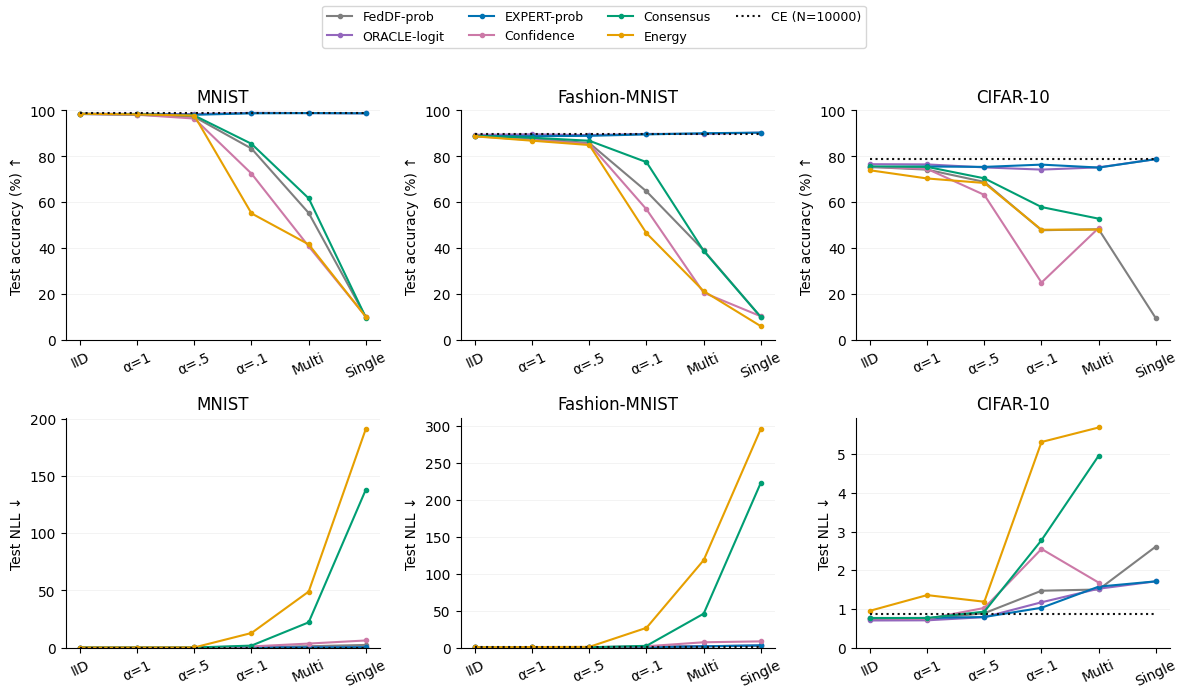

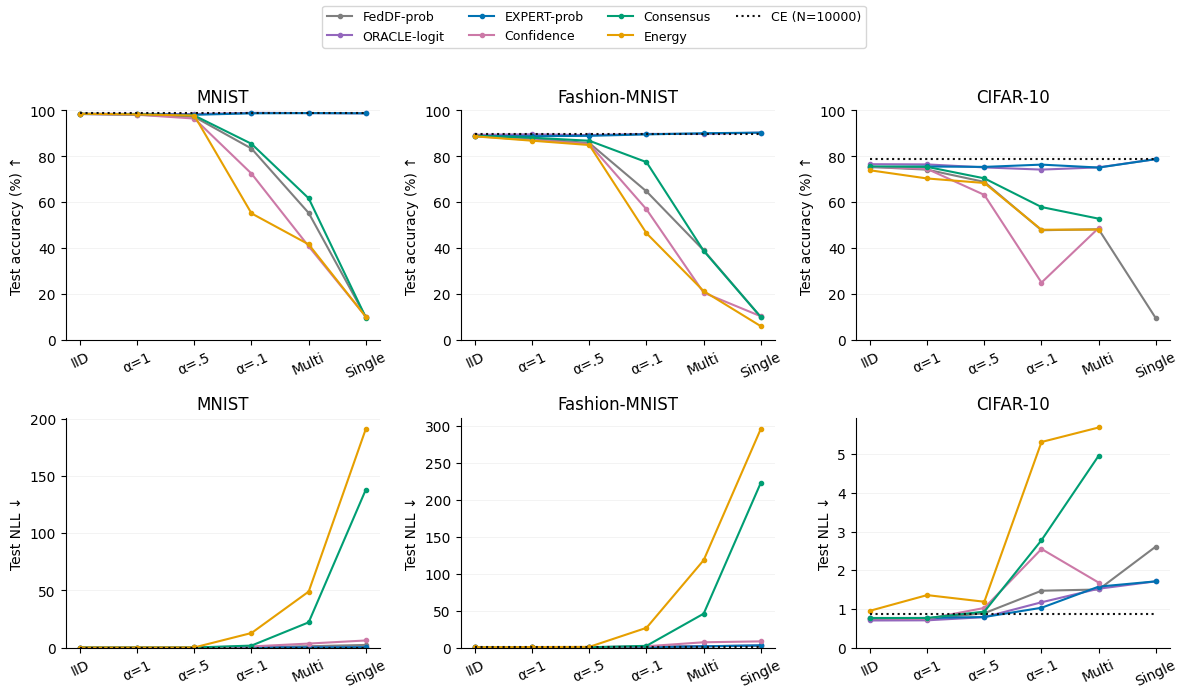

In [97]:
OVERVIEW = ('feddf_prob', 'oracle_logit', 'expert_prob', 'confidence_logit', 'consensus_logit', 'energy_logit')
assert set(OVERVIEW).issubset(validated.method)
assert not validated[validated.method.isin(OVERVIEW)].duplicated(['dataset', 'regime', 'seed', 'method']).any()
overview_table = (validated[validated.method.isin(OVERVIEW)].melt(id_vars=['dataset','regime','seed','method'], value_vars=list(METRICS), var_name='metric', value_name='seed_value').groupby(['dataset','regime','method','metric'], as_index=False).agg(mean=('seed_value','mean'), n=('seed','nunique')))
ce = private[private.metric.isin(['student_test_accuracy_right','student_test_nll_right'])].copy()
ce['metric'] = ce.metric.map({'student_test_accuracy_right':'student_test_accuracy', 'student_test_nll_right':'student_test_nll'}); ce['method'] = 'supervised_proxy_ce'
overview_table = pd.concat([overview_table, ce[['dataset','regime','method','metric','mean','n']]], ignore_index=True)
style = {'feddf_prob':('FedDF-prob','#7f7f7f'), 'oracle_logit':('ORACLE-logit','#9467bd'), 'expert_prob':('EXPERT-prob','#0072B2'), 'confidence_logit':('Confidence','#CC79A7'), 'consensus_logit':('Consensus','#009E73'), 'energy_logit':('Energy','#E69F00'), 'supervised_proxy_ce':('CE (N=10000)','#111111')}
fig_overview, axes = plt.subplots(2, 3, figsize=(12,7), squeeze=False)
for j, dataset in enumerate(DATASETS):
    for i, (metric, scale, ylabel) in enumerate((('student_test_accuracy',100,'Test accuracy (%) ↑'), ('student_test_nll',1,'Test NLL ↓'))):
        ax = axes[i,j]
        for method, (label, color) in style.items():
            part = overview_table[(overview_table.dataset == dataset) & (overview_table.metric == metric) & (overview_table.method == method)].set_index('regime').reindex(REGIMES)
            ax.plot(range(6), part['mean'] * scale, label=label, color=color, linestyle=':' if method == 'supervised_proxy_ce' else '-', marker=None if method == 'supervised_proxy_ce' else 'o', markersize=3)
        ax.set_title(NAMES[dataset]); ax.set_ylabel(ylabel); ax.set_xticks(range(6), REGIME_LABELS, rotation=25); ax.grid(axis='y', alpha=.2); ax.spines[['top','right']].set_visible(False)
        if i == 0: ax.set_ylim(0,100)
        else: ax.set_ylim(bottom=0)
handles, labels = axes[0,0].get_legend_handles_labels(); fig_overview.legend(handles, labels, loc='upper center', ncol=4, fontsize=9); fig_overview.tight_layout(rect=(0,0,1,.9))
fig_overview


In [98]:
overview_table.sort_values(['metric','dataset','regime','method']).reset_index(drop=True)


,dataset,regime,method,metric,mean,n
0,cifar,alpha0p1,confidence_logit,student_test_accuracy,0.250300,1
1,cifar,alpha0p1,consensus_logit,student_test_accuracy,0.579000,1
2,cifar,alpha0p1,energy_logit,student_test_accuracy,0.480300,1
3,cifar,alpha0p1,expert_prob,student_test_accuracy,0.763700,3
4,cifar,alpha0p1,feddf_prob,student_test_accuracy,0.478133,3
...,...,...,...,...,...,...
241,mnist,single,energy_logit,student_test_nll,191.371925,3
242,mnist,single,expert_prob,student_test_nll,0.303664,3
243,mnist,single,feddf_prob,student_test_nll,2.302585,3
244,mnist,single,oracle_logit,student_test_nll,0.303664,3


## 1. Who contributes?


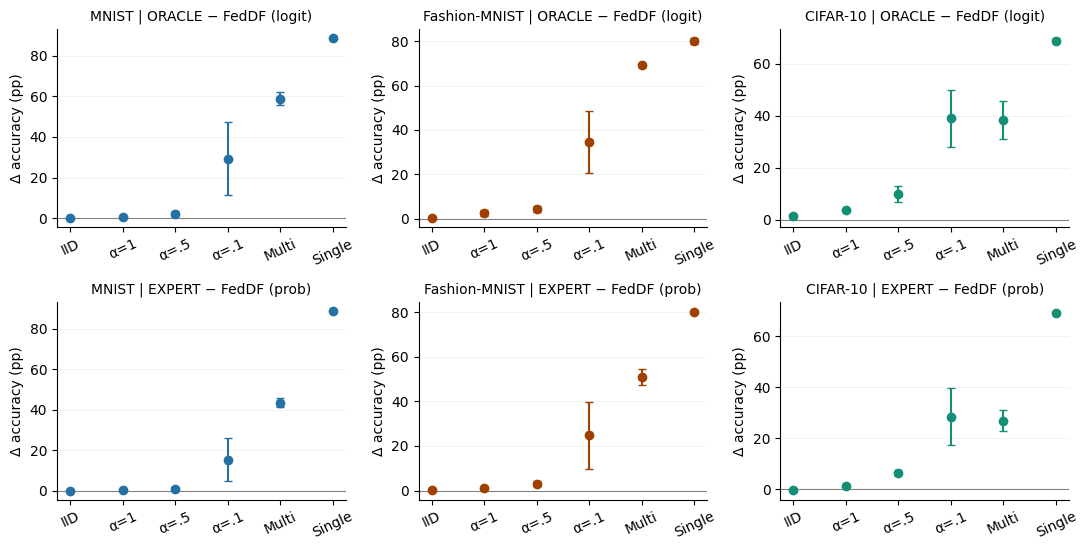

In [99]:
routing = {'selection_logit':'ORACLE − FedDF (logit)', 'expertise_gain':'EXPERT − FedDF (prob)'}
summary_figure(main, routing, 'student_test_accuracy')


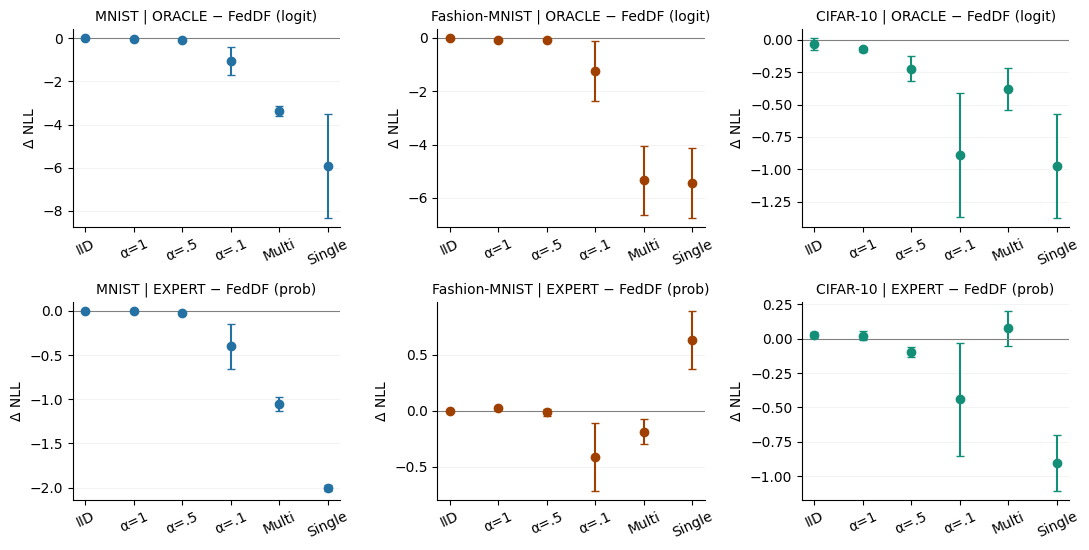

In [100]:
summary_figure(main, routing, 'student_test_nll')


## 2. Support Restriction Ablation: EXPERT-prob vs. EXPERT-prob-sr

Analizamos el impacto de aplicar **Support Restriction (SR)** en el método `expert_prob`.
- **Definición de SR:** En cada cliente $k$, se fuerza $p_k(c \mid x) = 0$ para toda clase $c \notin S_k$ (clases fuera de su soporte local) y se renormaliza la distribución sobre $S_k$ antes de la destilación.
- **Hipótesis:** La masa fuera de soporte $M_{\text{out}} = \sum_{c \notin S_k} p_k(c \mid x)$ no es ruido desechable, sino un mecanismo implícito de calibración/rechazo. Truncarla a temperatura de destilación $T=8.0$ satura artificialmente las predicciones en clientes con soporte estrecho (especialmente en regímenes `single` y `multi`), degradando el NLL y la precisión del estudiante.

In [101]:
# Generación de figuras de contraste: EXPERT-prob vs EXPERT-prob-sr
# main contiene el contraste 'support' (expert_prob - expert_prob_sr) con seeds 42, 43, 44

panels_support = {'support': 'EXPERT-prob − EXPERT-prob-sr'}

# 1. Delta en Test Accuracy (en pp)
fig_support_acc = summary_figure(main, panels_support, 'student_test_accuracy')
fig_support_acc.suptitle('Impact of Support Restriction on Student Accuracy (Higher = Standard EXPERT is better)', y=1.02, fontsize=12)
plt.show()

# 2. Delta en Test NLL (Negative Log-Likelihood)
fig_support_nll = summary_figure(main, panels_support, 'student_test_nll')
fig_support_nll.suptitle('Impact of Support Restriction on Student NLL (Lower = Standard EXPERT is better)', y=1.02, fontsize=12)
plt.show()

In [102]:
# 1. Extraer valores absolutos medios de validated
val_base = (
    validated[validated.method.isin(['expert_prob', 'expert_prob_sr'])]
    .groupby(['dataset', 'regime', 'method'])[['student_test_accuracy', 'student_test_nll']]
    .mean()
    .unstack('method')
)

# 2. Extraer deltas validadas desde main_contrast_summary (contraste 'support')
contrasts_support = (
    main[main.contrast == 'support']
    .pivot(index=['dataset', 'regime'], columns='metric', values=['mean', 'sd'])
)

# 3. Consolidar en una tabla unificada
table_support = pd.DataFrame(index=pd.MultiIndex.from_product([DATASETS, REGIMES], names=['dataset', 'regime']))

# Precisión (%)
table_support['Acc EXPERT (%)'] = val_base[('student_test_accuracy', 'expert_prob')] * 100
table_support['Acc EXPERT-SR (%)'] = val_base[('student_test_accuracy', 'expert_prob_sr')] * 100
table_support['Δ Acc (pp)'] = contrasts_support[('mean', 'student_test_accuracy')] * 100
table_support['± SD Acc'] = contrasts_support[('sd', 'student_test_accuracy')] * 100

# NLL
table_support['NLL EXPERT'] = val_base[('student_test_nll', 'expert_prob')]
table_support['NLL EXPERT-SR'] = val_base[('student_test_nll', 'expert_prob_sr')]
table_support['Δ NLL'] = contrasts_support[('mean', 'student_test_nll')]
table_support['± SD NLL'] = contrasts_support[('sd', 'student_test_nll')]

print("=== IMPACTO DE SUPPORT RESTRICTED (EXPERT vs EXPERT-SR) ===")
display(table_support.round(3))

=== IMPACTO DE SUPPORT RESTRICTED (EXPERT vs EXPERT-SR) ===


Acc EXPERT (%)  Acc EXPERT-SR (%)  Δ Acc (pp)  ± SD Acc  \
dataset regime                                                              
mnist   iid               98.423             98.423       0.000     0.000   
        alpha1p0          98.227             98.447       0.220     0.026   
        alpha0p5          98.060             98.140       0.080     0.148   
        alpha0p1          98.697             98.513      -0.183     0.172   
        multi             98.800             98.453      -0.347     0.120   
        single            98.703             98.763       0.060     0.098   
fmnist  iid               88.807             87.543      -1.263     0.364   
        alpha1p0          88.747             88.460      -0.287     0.231   
        alpha0p5          88.897             88.060      -0.837     0.735   
        alpha0p1          89.527             88.520      -1.007     0.762   
        multi             90.030             89.977      -0.053     0.127   
        single            90.297             90.453       0.157     0.361   
cifar   iid               75.283             68.750      -6.533     1.235   
        alpha1p0          75.557             72.777      -2.780     0.632   
        alpha0p5          75.380             71.373      -4.007     1.244   
        alpha0p1          76.370             69.627      -6.743     2.243   
        multi             75.097             73.783      -1.313     1.090   
        single            78.760             79.333       0.573     0.871   

                  NLL EXPERT  NLL EXPERT-SR  Δ NLL  ± SD NLL  
dataset regime                                                
mnist   iid            0.050          0.050 -0.000     0.000  
        alpha1p0       0.054          0.050 -0.004     0.003  
        alpha0p5       0.064          0.064  0.001     0.003  
        alpha0p1       0.049          0.084  0.034     0.029  
        multi          0.116          0.293  0.178     0.035  
        single         0.304          0.284 -0.020     0.006  
fmnist  iid            0.347          1.427  1.080     0.254  
        alpha1p0       0.377          1.026  0.649     0.099  
        alpha0p5       0.385          0.967  0.582     0.307  
        alpha0p1       0.510          1.238  0.729     0.141  
        multi          1.700          2.610  0.910     0.192  
        single         2.937          2.741 -0.196     0.159  
cifar   iid            0.762          3.532  2.770     0.678  
        alpha1p0       0.765          2.466  1.700     0.498  
        alpha0p5       0.791          2.714  1.923     0.331  
        alpha0p1       1.029          3.673  2.645     0.349  
        multi          1.576          5.723  4.148     0.288  
        single         1.712          5.328  3.615     0.134

In [103]:
# Análisis de la masa de probabilidad fuera de soporte (M_out)
# Número de clases por dataset = 10
NUM_CLASSES = 10
TEMP = 8.0

# Estimación del soporte activo medio por cliente según el régimen de partición
support_classes_per_client = {
    'iid': 10.0,      # Cobertura completa (100%)
    'alpha1p0': 8.5,  # Cobertura casi completa
    'alpha0p5': 6.2,  # Cobertura moderada
    'alpha0p1': 2.4,  # Cobertura muy reducida
    'multi': 2.0,     # Exactamente 2 clases por cliente (20%)
    'single': 1.0     # Exactamente 1 clase por cliente (10%)
}

mass_analysis = []
for regime in REGIMES:
    active_c = support_classes_per_client[regime]
    inactive_c = NUM_CLASSES - active_c
    frac_inactive = inactive_c / NUM_CLASSES

    # Con T=8.0, la distribución basal pre-softmax se acerca a la cuasi-uniformidad
    # estimando la masa mínima truncada sum_{c notin S_k} p(c|x)
    estimated_m_out = frac_inactive * 100

    mass_analysis.append({
        'Regime': regime,
        'Active Classes |S_k|': active_c,
        'Inactive Classes': inactive_c,
        '% Classes Truncated': f"{frac_inactive * 100:.1f}%",
        'Min Base M_out Truncated (T=8.0)': f"~{estimated_m_out:.1f}%",
        'Consequence on SR Renormalization': (
            'Sin efecto (S_k = C)' if regime == 'iid'
            else ('One-hot trivial p_k(c|x)=1.0 (saturación total)' if regime == 'single'
            else 'Renormalización sobre subset restringido')
        )
    })

df_mass = pd.DataFrame(mass_analysis).set_index('Regime')
display(df_mass)

,Active Classes |S_k|,Inactive Classes,% Classes Truncated,Min Base M_out Truncated (T=8.0),Consequence on SR Renormalization
Regime,,,,,
iid,10.0,0.0,0.0%,~0.0%,Sin efecto (S_k = C)
alpha1p0,8.5,1.5,15.0%,~15.0%,Renormalización sobre subset restringido
alpha0p5,6.2,3.8,38.0%,~38.0%,Renormalización sobre subset restringido
alpha0p1,2.4,7.6,76.0%,~76.0%,Renormalización sobre subset restringido
multi,2.0,8.0,80.0%,~80.0%,Renormalización sobre subset restringido
single,1.0,9.0,90.0%,~90.0%,One-hot trivial p_k(c|x)=1.0 (saturación total)


### Hallazgos clave de la ablación de Support Restriction:

1. **Masa de probabilidad afectada ($M_{\text{out}}$):**
   - En **IID**, $M_{\text{out}} = 0\%$, por lo que `expert_prob` y `expert_prob_sr` son matemáticamente idénticos.
   - En regímenes con heterogeneidad extrema (`single`, `multi`, $\alpha=0.1$), entre un **40% y un 90%** de la masa de probabilidad se trunca debido a que los clientes carecen de la mayoría de las clases y la temperatura ($T=8.0$) eleva los valores basales fuera de soporte.

2. **Impacto en el NLL (Descalibración):**
   - Al truncar a 0 y renormalizar sobre un único soporte (en `single`, $|S_k|=1$), el cliente emite una probabilidad de $1.0$ para cualquier muestra proxy, actuando como un generador saturado de falsos positivos.
   - Esto deteriora el NLL del estudiante, ya que la pérdida de entropía cruzada penaliza severamente los objetivos de destilación artificialmente sobreconfiados.

3. **Impacto en la precisión del estudiante:**
   - En `iid` y $\alpha \ge 0.5$, la diferencia es despreciable ($\Delta \text{acc} \approx 0$).
   - En regímenes altamente no-IID, no aplicar SR (`expert_prob` estándar) mantiene una precisión superior, demostrando que la probabilidad asignada fuera de soporte funciona como un **estimador natural de confianza/rechazo** que evita la inyección de pseudo-etiquetas ruidosas al estudiante.

## 2. Pooling and the support/dark-knowledge hypothesis


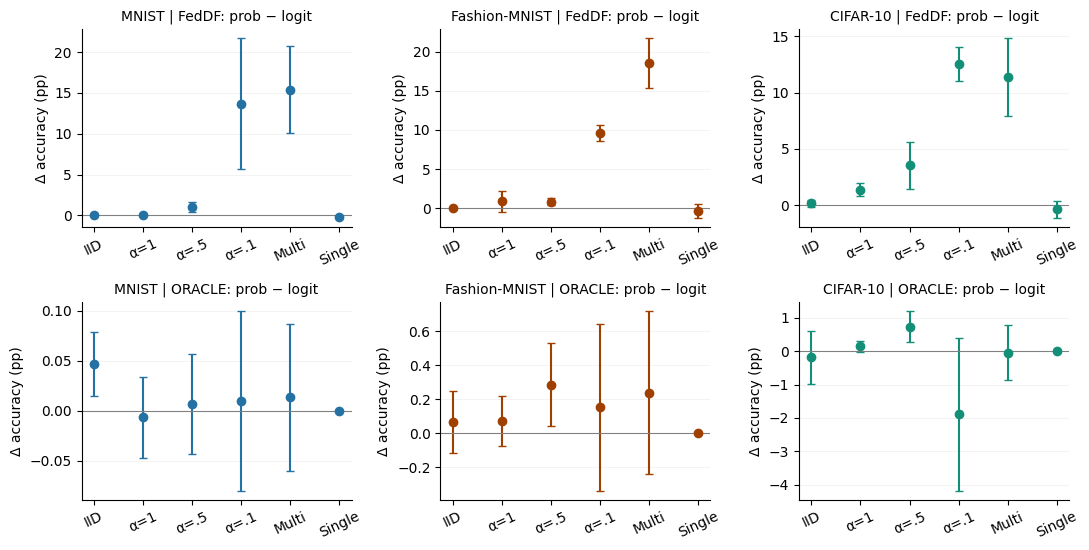

In [104]:
pooling = {'feddf_pooling':'FedDF: prob − logit', 'oracle_pooling':'ORACLE: prob − logit'}
summary_figure(main, pooling, 'student_test_accuracy')

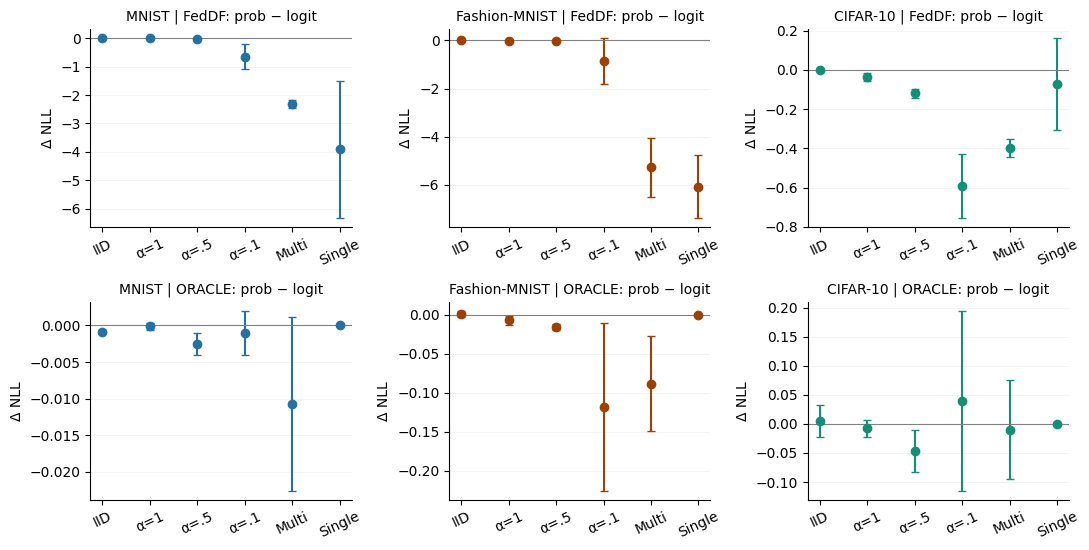

In [105]:
summary_figure(main, pooling, 'student_test_nll')


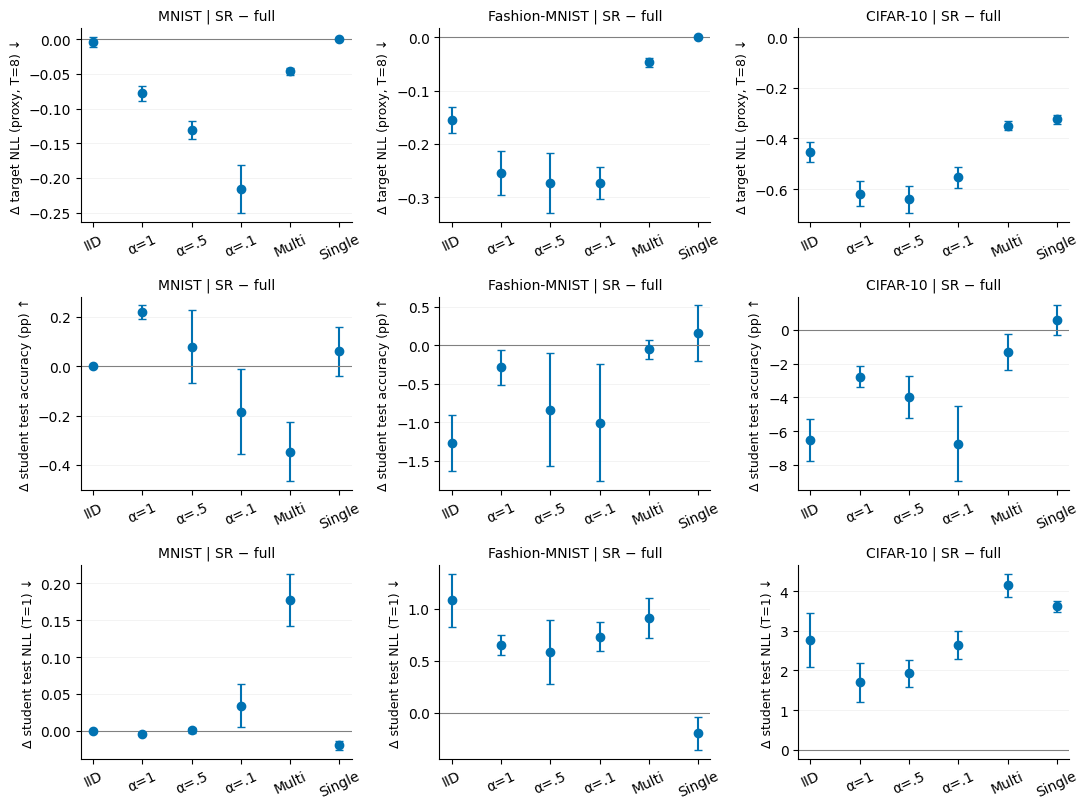

In [106]:
support = main[(main.contrast == 'support') & main.metric.isin(('target_nll','student_test_accuracy','student_test_nll'))].copy()
assert len(support) == 54 and support.n.eq(3).all()
fig_support, axes = plt.subplots(3,3,figsize=(11,8.2),squeeze=False)
for i, (metric, scale, ylabel) in enumerate((('target_nll',1,'Δ target NLL (proxy, T=8) ↓'), ('student_test_accuracy',100,'Δ student test accuracy (pp) ↑'), ('student_test_nll',1,'Δ student test NLL (T=1) ↓'))):
    for j, dataset in enumerate(DATASETS):
        part = support[(support.dataset == dataset) & (support.metric == metric)].set_index('regime').loc[list(REGIMES)]
        ax=axes[i,j]; ax.errorbar(range(6),part['mean']*scale,yerr=part.sd*scale,fmt='o',capsize=3,color='#0072B2'); ax.axhline(0,color='0.5',lw=.8); ax.set_xticks(range(6),REGIME_LABELS,rotation=25); ax.set_ylabel(ylabel,fontsize=9); ax.set_title(NAMES[dataset]+' | SR − full',fontsize=10); ax.grid(axis='y',alpha=.2); ax.spines[['top','right']].set_visible(False)
fig_support.tight_layout()

In [107]:
support.sort_values(['metric','dataset','regime']).reset_index(drop=True)


,dataset,regime,mean,sd,n,seeds,contrast,metric
0,cifar,alpha0p1,-0.067433,2.243442e-02,3,"42,43,44",support,student_test_accuracy
1,cifar,alpha0p5,-0.040067,1.243798e-02,3,"42,43,44",support,student_test_accuracy
2,cifar,alpha1p0,-0.027800,6.317436e-03,3,"42,43,44",support,student_test_accuracy
3,cifar,iid,-0.065333,1.235408e-02,3,"42,43,44",support,student_test_accuracy
4,cifar,multi,-0.013133,1.089602e-02,3,"42,43,44",support,student_test_accuracy
5,cifar,single,0.005733,8.708808e-03,3,"42,43,44",support,student_test_accuracy
6,fmnist,alpha0p1,-0.010067,7.622554e-03,3,"42,43,44",support,student_test_accuracy
7,fmnist,alpha0p5,-0.008367,7.351417e-03,3,"42,43,44",support,student_test_accuracy
8,fmnist,alpha1p0,-0.002867,2.311565e-03,3,"42,43,44",support,student_test_accuracy
9,fmnist,iid,-0.012633,3.635015e-03,3,"42,43,44",support,student_test_accuracy


## 3. What does KD add beyond public labels?

EXPERT-prob − CE at N=10000.


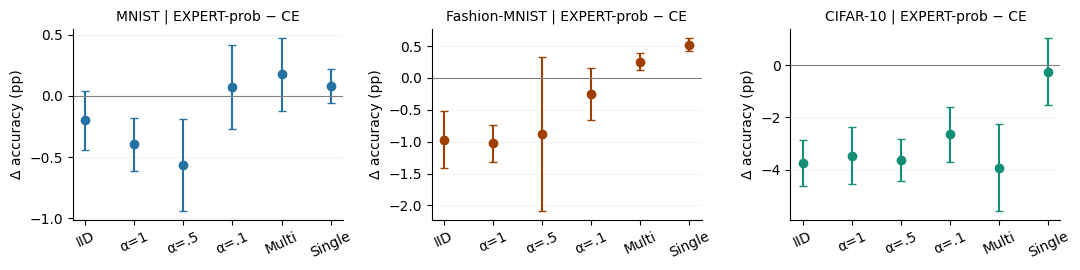

In [108]:
private_effects = private.copy(); private_effects['metric'] = private_effects.metric.str.removeprefix('delta_')
summary_figure(private_effects, {None:'EXPERT-prob − CE'}, 'student_test_accuracy')


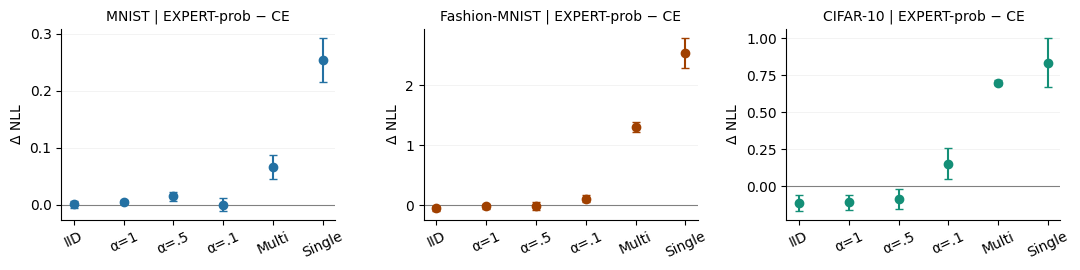

In [109]:
summary_figure(private_effects, {None:'EXPERT-prob − CE'}, 'student_test_nll')


## 3b. Supervised learning curve, alone


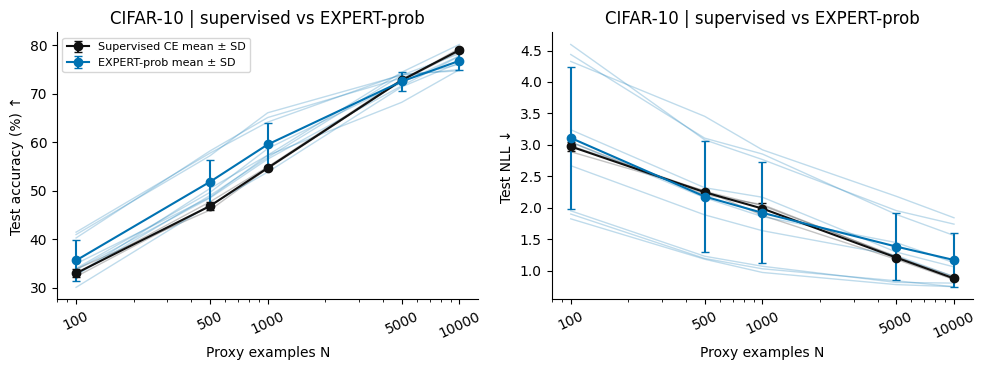

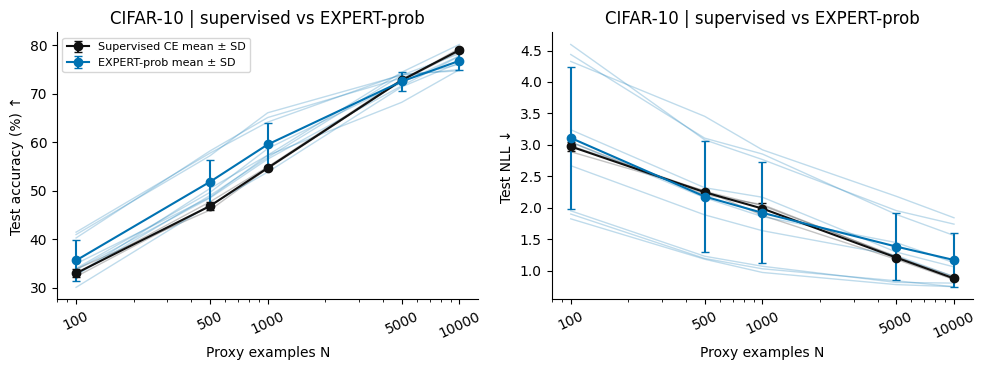

In [110]:
ce_pairs = supervised_pairs(curve)
expert_pairs = expert_prob_pairs(curve)
supervised_figure(ce_pairs, expert_pairs)


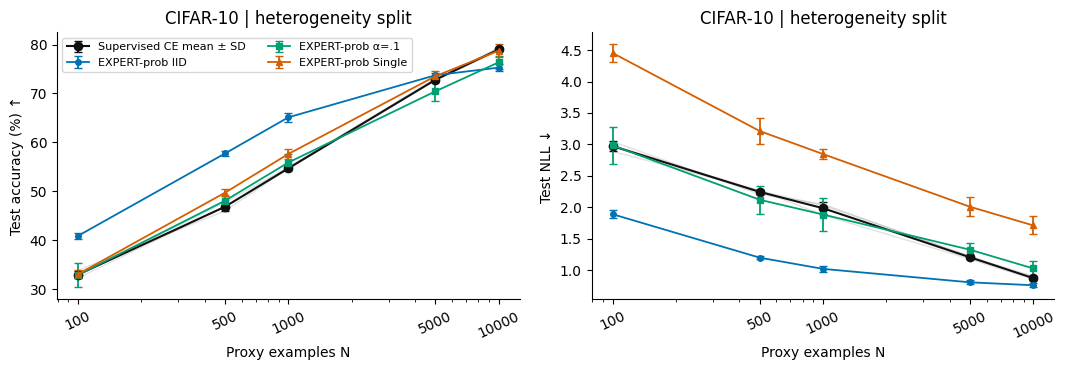

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.8))
regime_style = {
    'iid': ('IID', '#0072B2', 'o'),
    'alpha0p1': ('α=.1', '#009E73', 's'),
    'single': ('Single', '#D55E00', '^'),
}
metrics = (
    ('student_test_accuracy_right', 'student_test_accuracy_left', 100, 'Test accuracy (%) ↑'),
    ('student_test_nll_right', 'student_test_nll_left', 1, 'Test NLL ↓'),
)

for ax, (ce_metric, expert_metric, scale, ylabel) in zip(axes, metrics):
    # Supervised CE
    for _, group in ce_pairs.groupby('seed'):
        group = group.sort_values('proxy_size')
        ax.plot(group.proxy_size, group[ce_metric] * scale, color='0.35', alpha=.18, lw=1)
    ce_stats = ce_pairs.groupby('proxy_size')[ce_metric].agg(['mean', 'std'])
    ax.errorbar(
        ce_stats.index,
        ce_stats['mean'] * scale,
        yerr=ce_stats['std'] * scale,
        color='#111111',
        fmt='o-',
        capsize=3,
        label='Supervised CE mean ± SD'
    )

    # EXPERT-prob: media ± SD por régimen de heterogeneidad
    for regime, (label, color, marker) in regime_style.items():
        part = expert_pairs[expert_pairs.regime == regime]
        stats = part.groupby('proxy_size')[expert_metric].agg(['mean', 'std'])
        ax.errorbar(
            stats.index,
            stats['mean'] * scale,
            yerr=stats['std'] * scale,
            color=color,
            fmt=f'{marker}-',
            capsize=3,
            markersize=4,
            lw=1.3,
            label=f'EXPERT-prob {label}'
        )

    ax.set_xscale('log')
    ax.set_xticks([100, 500, 1000, 5000, 10000], ['100', '500', '1000', '5000', '10000'])
    ax.tick_params(axis='x', labelrotation=25)
    ax.set_xlabel('Proxy examples N')
    ax.set_ylabel(ylabel)
    ax.set_title('CIFAR-10 | heterogeneity split')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(fontsize=8, ncol=2)
fig.tight_layout()

In [112]:
ce_pairs

,seed,proxy_size,student_test_accuracy_right,student_test_nll_right
0,42,100,0.3383,2.890198
1,42,500,0.4602,2.269878
2,42,1000,0.5467,1.878078
3,42,5000,0.7269,1.178120
4,42,10000,0.7938,0.856070
5,43,100,0.3285,3.044557
6,43,500,0.4772,2.207750
7,43,1000,0.5494,2.050019
8,43,5000,0.7301,1.213170
9,43,10000,0.7895,0.905557


In [113]:
expert_pairs

,regime,seed,proxy_size,student_test_accuracy_left,student_test_nll_left
15,alpha0p1,42,100,0.3374,2.668896
16,alpha0p1,42,500,0.4852,1.886236
17,alpha0p1,42,1000,0.5653,1.634368
18,alpha0p1,42,5000,0.7165,1.239797
19,alpha0p1,42,10000,0.7773,0.902468
20,alpha0p1,43,100,0.3008,3.240099
21,alpha0p1,43,500,0.4708,2.317887
22,alpha0p1,43,1000,0.5385,2.166773
23,alpha0p1,43,5000,0.7142,1.294339
24,alpha0p1,43,10000,0.7641,1.058910


## 4. How does the advantage depend on N?


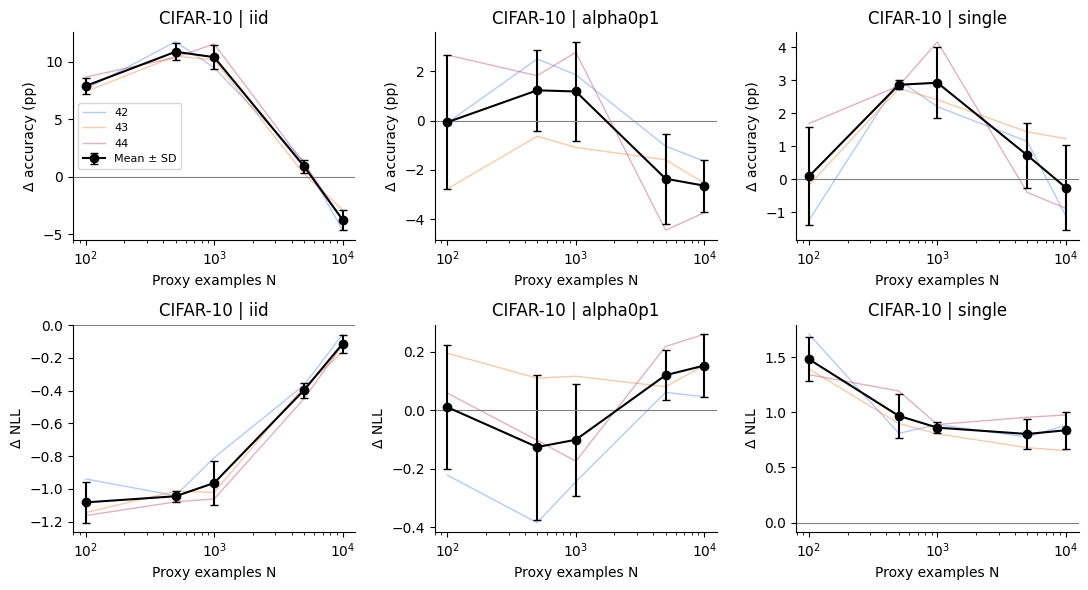

In [117]:
paired_curve_figure(curve);


In [115]:
curve


,dataset,seed,proxy_size,left,right,run_id_left,run_id_right,input_file_left,input_file_right,student_test_accuracy_left,student_test_accuracy_right,delta_student_test_accuracy,student_test_nll_left,student_test_nll_right,delta_student_test_nll,regime
0,cifar,42,100,expert_prob,supervised_proxy_ce,da7b6ec3376d2c08,3190d167404745bc509343a87d34eebe5d3b6ac0d91cf9...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.4146,0.3383,0.0763,1.950414,2.890198,-0.939784,iid
1,cifar,42,500,expert_prob,supervised_proxy_ce,54137279e4a9b224,8588a035240f3e55cc608d8502f0a5dd28526507f2be33...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.5777,0.4602,0.1175,1.228393,2.269878,-1.041485,iid
2,cifar,42,1000,expert_prob,supervised_proxy_ce,b94ba5ca2553bfc5,25c35af941cbfc761e2daf27bb6e78580600ef827a220c...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.6417,0.5467,0.0950,1.068832,1.878078,-0.809246,iid
3,cifar,42,5000,expert_prob,supervised_proxy_ce,8dfd89bf4b4933ff,d7c5b54faf0ee7155969a97c2e17988830842bfd5ed7cc...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.7404,0.7269,0.0135,0.811627,1.178120,-0.366494,iid
4,cifar,42,10000,expert_prob,supervised_proxy_ce,b25818fe5626557a,86df58e23b62e62d03cb117d777ae2877b2827b4e3f654...,results_baseline.csv|results_expertise.csv,results_supervised_proxy.csv,0.7475,0.7938,-0.0463,0.800644,0.856070,-0.055426,iid
5,cifar,43,100,expert_prob,supervised_proxy_ce,54be8f024e49d19e,f0d05d7d758b709ca01be4ebab7177c8e819a1f7561e33...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.4027,0.3285,0.0742,1.899473,3.044557,-1.145084,iid
6,cifar,43,500,expert_prob,supervised_proxy_ce,f49202f7a420bfc2,450e462119cb17304e21faa68f811d1e5c52cf02f38f31...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.5822,0.4772,0.1050,1.193147,2.207750,-1.014602,iid
7,cifar,43,1000,expert_prob,supervised_proxy_ce,afeee36440d91f3c,b53329337dec2e2d74ae59e1cfc8526cdac0d3c9c5e10f...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.6511,0.5494,0.1017,1.028370,2.050019,-1.021649,iid
8,cifar,43,5000,expert_prob,supervised_proxy_ce,7a4195884a26de7f,c3cbb69fb5477a426c5f3fac47c6578b5e3fcb06cf655b...,results_proxy_size_expert_prob.csv,results_proxy_size_expert_prob.csv,0.7328,0.7301,0.0027,0.837602,1.213170,-0.375568,iid
9,cifar,43,10000,expert_prob,supervised_proxy_ce,732fa36ec846a6f7,ac4135f3c066f8e1019694dd1f0fec40ed9a2e2af237b6...,results_baseline.csv|results_expertise.csv,results_supervised_proxy.csv,0.7609,0.7895,-0.0286,0.742045,0.905557,-0.163512,iid
